# Análise Multilayer: Alianças + Comércio + Disputas

Este notebook constrói e compara redes multilayer para os períodos pré-WWI (1890-1914) e pré-WWII (1925-1939).

**Camadas:**
1. **Alianças** - Pactos formais entre Estados (COW v4.1)
2. **Comércio** - Fluxos comerciais bilaterais (COW v4.0)
3. **Disputas** - Disputas militarizadas interestatais (MIDs v5.0)

**Filtro:** Estados com CINC >= 1% (grandes potências)

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Módulos locais
from src.etl.load_cow import load_alliances, load_trade, load_mids, load_nmc
from src.etl.transform import prepare_alliance_edges, filter_states_by_cinc
from src.network.build_network import build_alliance_network, build_trade_network, merge_networks
from src.network.metrics import calculate_centrality_metrics, calculate_global_metrics, calculate_community_metrics
from src.visualization.gephi_export import export_to_gexf

# Configurações
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', None)

# Seed para reprodutibilidade
np.random.seed(42)

print('Bibliotecas carregadas com sucesso!')

Bibliotecas carregadas com sucesso!


## 1. Definição de Parâmetros

In [2]:
# Janelas temporais
PERIODS = {
    'pre_wwi': {'start': 1890, 'end': 1914, 'label': 'Pré-WWI (1890-1914)'},
    'pre_wwii': {'start': 1925, 'end': 1939, 'label': 'Pré-WWII (1925-1939)'}
}

# Limiar CINC (será testado para robustez)
CINC_THRESHOLD = 0.01  # 1% do poder mundial

# Caminhos
DATA_PATH = Path('../data')
OUTPUT_PATH = DATA_PATH / 'output'
OUTPUT_PATH.mkdir(exist_ok=True)

print(f'Períodos: {list(PERIODS.keys())}')
print(f'Limiar CINC: {CINC_THRESHOLD}')

Períodos: ['pre_wwi', 'pre_wwii']
Limiar CINC: 0.01


## 2. Funções Auxiliares

In [3]:
def get_major_powers(start_year, end_year, cinc_threshold=0.01):
    """Retorna lista de Estados com CINC médio >= threshold no período."""
    nmc = load_nmc(start_year, end_year)
    
    # Calcular CINC médio por Estado
    avg_cinc = nmc.groupby('ccode')['cinc'].mean().reset_index()
    avg_cinc.columns = ['ccode', 'avg_cinc']
    
    # Filtrar por threshold
    major_powers = avg_cinc[avg_cinc['avg_cinc'] >= cinc_threshold]['ccode'].tolist()
    
    # Obter nomes
    names = nmc[['ccode', 'stateabb']].drop_duplicates().set_index('ccode')['stateabb']
    
    return major_powers, names.to_dict()


def prepare_trade_edges(df_trade, valid_states, year_range):
    """Prepara arestas de comércio agregando fluxos no período."""
    # Filtrar Estados válidos
    df = df_trade[
        (df_trade['ccode1'].isin(valid_states)) & 
        (df_trade['ccode2'].isin(valid_states))
    ].copy()
    
    # Usar smoothtotrade (comércio total suavizado)
    # Valores -9 são missing
    df = df[df['smoothtotrade'] > 0]
    
    # Agregar por díade (soma de todo período)
    edges = df.groupby(['ccode1', 'ccode2']).agg({
        'smoothtotrade': 'sum'
    }).reset_index()
    
    edges.columns = ['source', 'target', 'weight']
    
    return edges


def prepare_dispute_edges(start_year, end_year, valid_states):
    """Prepara arestas de disputas a partir de MIDs."""
    # Carregar disputas (MIDA) e participantes (MIDB)
    mida_path = DATA_PATH / 'raw' / 'cow' / 'mids' / 'MIDA 5.0.csv'
    midb_path = DATA_PATH / 'raw' / 'cow' / 'mids' / 'MIDB 5.0.csv'
    
    mida = pd.read_csv(mida_path)
    midb = pd.read_csv(midb_path)
    
    # Filtrar disputas no período
    mida = mida[(mida['styear'] >= start_year) & (mida['styear'] <= end_year)]
    
    # Filtrar participantes das disputas selecionadas
    midb = midb[midb['dispnum'].isin(mida['dispnum'])]
    
    # Filtrar Estados válidos
    midb = midb[midb['ccode'].isin(valid_states)]
    
    # Criar arestas: pares em lados OPOSTOS da mesma disputa
    edges_list = []
    
    for dispnum in midb['dispnum'].unique():
        participants = midb[midb['dispnum'] == dispnum]
        
        # Side A (sidea == 1) vs Side B (sidea == 0)
        side_a = participants[participants['sidea'] == 1]['ccode'].tolist()
        side_b = participants[participants['sidea'] == 0]['ccode'].tolist()
        
        # Criar arestas entre lados opostos
        for s1 in side_a:
            for s2 in side_b:
                edges_list.append({'source': min(s1, s2), 'target': max(s1, s2), 'dispnum': dispnum})
    
    if not edges_list:
        return pd.DataFrame(columns=['source', 'target', 'weight'])
    
    edges_df = pd.DataFrame(edges_list)
    
    # Contar disputas por díade
    edges = edges_df.groupby(['source', 'target']).size().reset_index(name='weight')
    
    return edges


print('Funções auxiliares definidas.')

Funções auxiliares definidas.


## 3. Construção das Redes por Período

In [4]:
def build_all_networks(period_key, cinc_threshold=0.01):
    """Constrói as 3 camadas de rede para um período."""
    period = PERIODS[period_key]
    start, end = period['start'], period['end']
    
    print(f"\n{'='*60}")
    print(f"Construindo redes para {period['label']}")
    print(f"{'='*60}")
    
    # 1. Obter Estados relevantes (CINC filter)
    major_powers, names = get_major_powers(start, end, cinc_threshold)
    print(f"\nEstados com CINC >= {cinc_threshold}: {len(major_powers)}")
    print([names.get(c, c) for c in major_powers])
    
    networks = {}
    
    # 2. REDE DE ALIANÇAS
    print("\n--- Rede de Alianças ---")
    df_alliances = load_alliances(start, end)
    edges_alliances = prepare_alliance_edges(df_alliances, start, end)
    edges_alliances = edges_alliances[
        (edges_alliances['source'].isin(major_powers)) & 
        (edges_alliances['target'].isin(major_powers))
    ]
    
    # Remover duplicatas
    edges_alliances = edges_alliances.sort_values('weight', ascending=False)
    edges_alliances = edges_alliances.drop_duplicates(subset=['source', 'target'], keep='first')
    
    G_alliance = build_alliance_network(edges_alliances)
    
    # Adicionar nomes aos nós
    for node in G_alliance.nodes():
        G_alliance.nodes[node]['name'] = names.get(node, str(node))
    
    networks['alliance'] = G_alliance
    print(f"Nós: {G_alliance.number_of_nodes()}, Arestas: {G_alliance.number_of_edges()}")
    
    # 3. REDE DE COMÉRCIO
    print("\n--- Rede de Comércio ---")
    df_trade = load_trade(start, end)
    edges_trade = prepare_trade_edges(df_trade, major_powers, (start, end))
    
    G_trade = build_trade_network(edges_trade, normalize_weights=True)
    
    # Adicionar nomes
    for node in G_trade.nodes():
        G_trade.nodes[node]['name'] = names.get(node, str(node))
    
    networks['trade'] = G_trade
    print(f"Nós: {G_trade.number_of_nodes()}, Arestas: {G_trade.number_of_edges()}")
    
    # 4. REDE DE DISPUTAS
    print("\n--- Rede de Disputas ---")
    edges_disputes = prepare_dispute_edges(start, end, major_powers)
    
    G_disputes = nx.Graph()
    for _, row in edges_disputes.iterrows():
        G_disputes.add_edge(row['source'], row['target'], weight=row['weight'])
    
    # Adicionar nomes
    for node in G_disputes.nodes():
        G_disputes.nodes[node]['name'] = names.get(node, str(node))
    
    networks['disputes'] = G_disputes
    print(f"Nós: {G_disputes.number_of_nodes()}, Arestas: {G_disputes.number_of_edges()}")
    
    return networks, names


# Construir redes para ambos os períodos
networks_wwi, names_wwi = build_all_networks('pre_wwi', CINC_THRESHOLD)
networks_wwii, names_wwii = build_all_networks('pre_wwii', CINC_THRESHOLD)


Construindo redes para Pré-WWI (1890-1914)

Estados com CINC >= 0.01: 12
['USA', 'UKG', 'BEL', 'FRN', 'SPN', 'GMY', 'AUH', 'ITA', 'RUS', 'TUR', 'CHN', 'JPN']

--- Rede de Alianças ---
Nós: 11, Arestas: 21

--- Rede de Comércio ---
Nós: 12, Arestas: 62

--- Rede de Disputas ---
Nós: 12, Arestas: 41

Construindo redes para Pré-WWII (1925-1939)

Estados com CINC >= 0.01: 13
['USA', 'BRA', 'UKG', 'BEL', 'FRN', 'SPN', 'GMY', 'POL', 'CZE', 'ITA', 'RUS', 'CHN', 'JPN']

--- Rede de Alianças ---
Nós: 13, Arestas: 33

--- Rede de Comércio ---
Nós: 13, Arestas: 77

--- Rede de Disputas ---
Nós: 13, Arestas: 57


## 4. Cálculo de Métricas por Camada

In [5]:
def compute_layer_metrics(networks, period_label):
    """Calcula métricas globais para cada camada."""
    results = []
    
    for layer_name, G in networks.items():
        if G.number_of_nodes() == 0:
            continue
            
        metrics = {
            'period': period_label,
            'layer': layer_name,
            'nodes': G.number_of_nodes(),
            'edges': G.number_of_edges(),
            'density': nx.density(G),
            'avg_degree': sum(dict(G.degree()).values()) / G.number_of_nodes(),
            'avg_clustering': nx.average_clustering(G),
        }
        
        # Componentes conectados
        if nx.is_connected(G):
            metrics['diameter'] = nx.diameter(G)
            metrics['avg_path_length'] = nx.average_shortest_path_length(G)
        else:
            metrics['diameter'] = None
            metrics['avg_path_length'] = None
        
        # Modularidade (Louvain)
        try:
            import community as community_louvain
            partition = community_louvain.best_partition(G)
            metrics['modularity'] = community_louvain.modularity(partition, G)
            metrics['n_communities'] = len(set(partition.values()))
        except:
            metrics['modularity'] = None
            metrics['n_communities'] = None
        
        results.append(metrics)
    
    return pd.DataFrame(results)


# Calcular métricas
metrics_wwi = compute_layer_metrics(networks_wwi, 'Pré-WWI')
metrics_wwii = compute_layer_metrics(networks_wwii, 'Pré-WWII')

# Combinar
all_metrics = pd.concat([metrics_wwi, metrics_wwii], ignore_index=True)
print("\nMétricas por Camada e Período:")
all_metrics


Métricas por Camada e Período:


,period,layer,nodes,edges,density,avg_degree,avg_clustering,diameter,avg_path_length,modularity,n_communities
0,Pré-WWI,alliance,11,21,0.381818,3.818182,0.363636,4,1.872727,0.247226,3
1,Pré-WWI,trade,12,62,0.939394,10.333333,0.950168,2,1.060606,0.100176,2
2,Pré-WWI,disputes,12,41,0.621212,6.833333,0.675331,3,1.424242,0.170817,3
3,Pré-WWII,alliance,13,33,0.423077,5.076923,0.615690,4,1.743590,0.141250,3
4,Pré-WWII,trade,13,77,0.987179,11.846154,0.987179,2,1.012821,0.062024,3
5,Pré-WWII,disputes,13,57,0.730769,8.769231,0.803097,2,1.307692,0.157972,3


## 5. Comparação Visual das Métricas

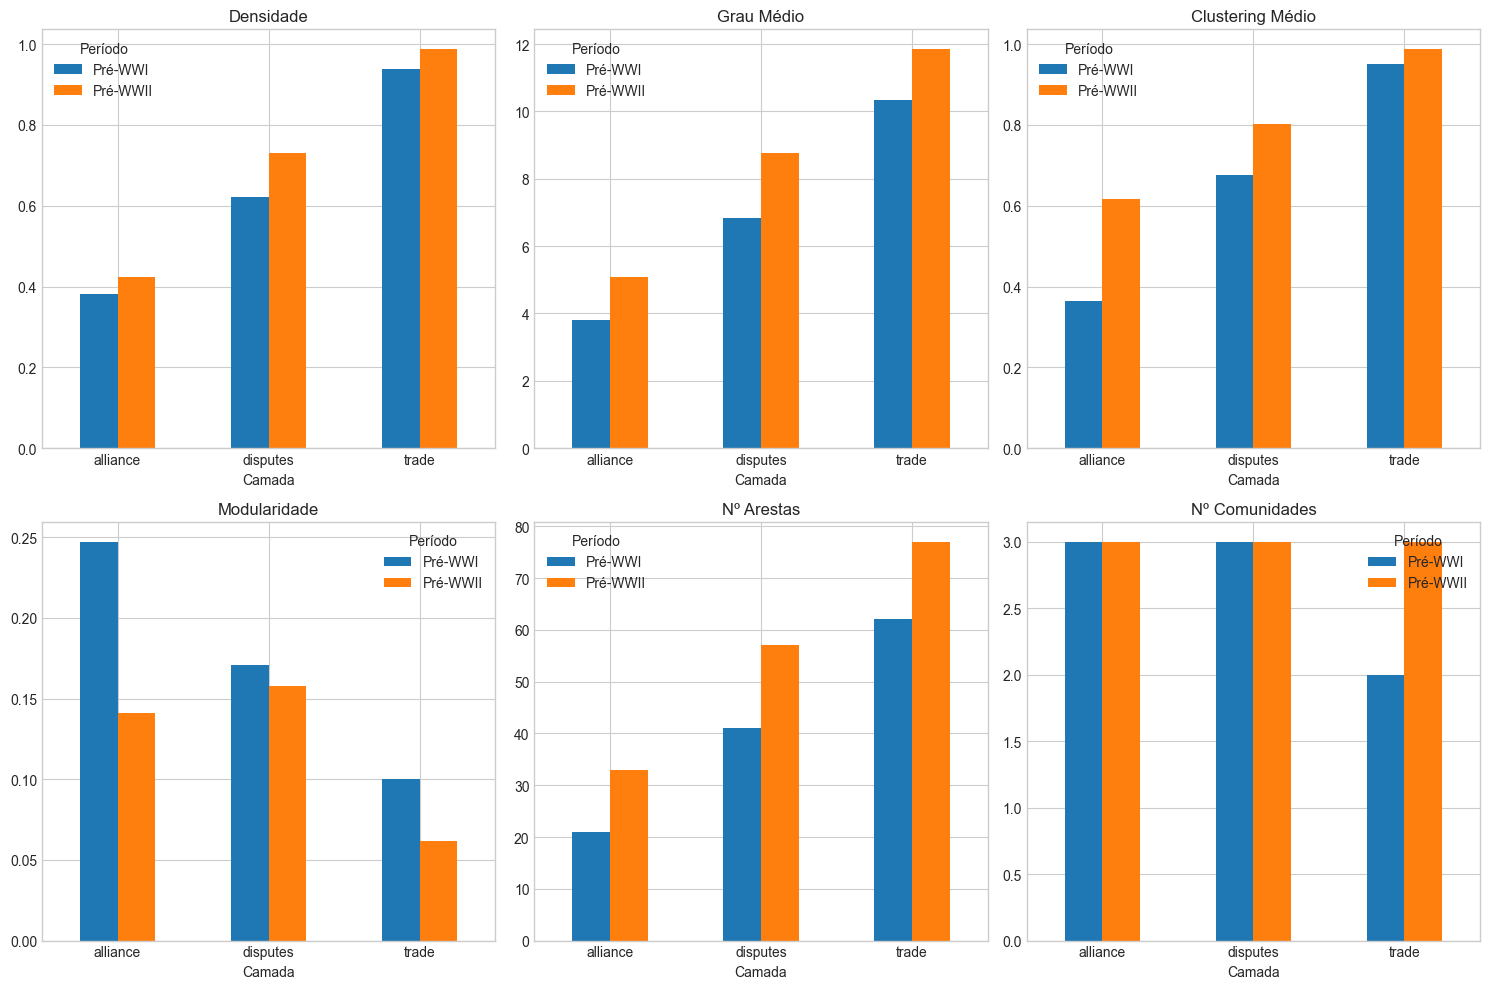

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

metrics_to_plot = ['density', 'avg_degree', 'avg_clustering', 'modularity', 'edges', 'n_communities']
titles = ['Densidade', 'Grau Médio', 'Clustering Médio', 'Modularidade', 'Nº Arestas', 'Nº Comunidades']

for ax, metric, title in zip(axes.flat, metrics_to_plot, titles):
    data = all_metrics.pivot(index='layer', columns='period', values=metric)
    data.plot(kind='bar', ax=ax, rot=0)
    ax.set_title(title)
    ax.set_xlabel('Camada')
    ax.legend(title='Período')

plt.tight_layout()
plt.savefig(OUTPUT_PATH / 'comparacao_camadas.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Centralidade por Camada

In [7]:
def compute_centrality(G, names_dict):
    """Calcula centralidades para um grafo."""
    if G.number_of_nodes() == 0:
        return pd.DataFrame()
    
    centrality = pd.DataFrame({
        'ccode': list(G.nodes()),
        'name': [names_dict.get(n, n) for n in G.nodes()],
        'degree': [G.degree(n) for n in G.nodes()],
        'betweenness': list(nx.betweenness_centrality(G).values()),
        'closeness': list(nx.closeness_centrality(G).values()),
    })
    
    try:
        centrality['eigenvector'] = list(nx.eigenvector_centrality(G, max_iter=1000).values())
    except:
        centrality['eigenvector'] = 0
    
    return centrality.sort_values('degree', ascending=False)


# Centralidade para cada camada e período
print("\n" + "="*60)
print("CENTRALIDADE PRÉ-WWI")
print("="*60)

for layer, G in networks_wwi.items():
    if G.number_of_nodes() > 0:
        print(f"\n--- {layer.upper()} ---")
        display(compute_centrality(G, names_wwi).head(5))

print("\n" + "="*60)
print("CENTRALIDADE PRÉ-WWII")
print("="*60)

for layer, G in networks_wwii.items():
    if G.number_of_nodes() > 0:
        print(f"\n--- {layer.upper()} ---")
        display(compute_centrality(G, names_wwii).head(5))


CENTRALIDADE PRÉ-WWI

--- ALLIANCE ---


,ccode,name,degree,betweenness,closeness,eigenvector
1,365,RUS,6,0.375926,0.714286,0.357449
7,325,ITA,6,0.057407,0.666667,0.444390
2,255,GMY,5,0.211111,0.625000,0.341517
3,200,UKG,5,0.116667,0.588235,0.350646
6,300,AUH,5,0.037037,0.625000,0.389605



--- TRADE ---


,ccode,name,degree,betweenness,closeness,eigenvector
0,2,USA,11,0.009163,1.0,0.302834
1,200,UKG,11,0.009163,1.0,0.302834
2,211,BEL,11,0.009163,1.0,0.302834
3,220,FRN,11,0.009163,1.0,0.302834
5,255,GMY,11,0.009163,1.0,0.302834



--- DISPUTES ---


...

,ccode,name,degree,betweenness,closeness,eigenvector
0,220,FRN,9,0.176768,0.800000,0.408388
1,325,ITA,8,0.092172,0.705882,0.374951
4,200,UKG,8,0.113636,0.750000,0.384746
5,255,GMY,8,0.080808,0.705882,0.383399
6,365,RUS,7,0.188131,0.666667,0.317098



--- TRADE ---


,ccode,name,degree,betweenness,closeness,eigenvector
0,2,USA,12,0.001377,1.0,0.280367
2,200,UKG,12,0.001377,1.0,0.280367
3,211,BEL,12,0.001377,1.0,0.280367
4,220,FRN,12,0.001377,1.0,0.280367
5,230,SPN,12,0.001377,1.0,0.280367



--- DISPUTES ---


,ccode,name,degree,betweenness,closeness,eigenvector
2,220,FRN,13,0.033670,0.923077,0.362122
5,325,ITA,13,0.033670,0.923077,0.362122
6,365,RUS,13,0.033670,0.923077,0.362122
4,255,GMY,11,0.136364,0.923077,0.306701
3,230,SPN,10,0.030303,0.857143,0.301335


## 7. Visualização das Redes

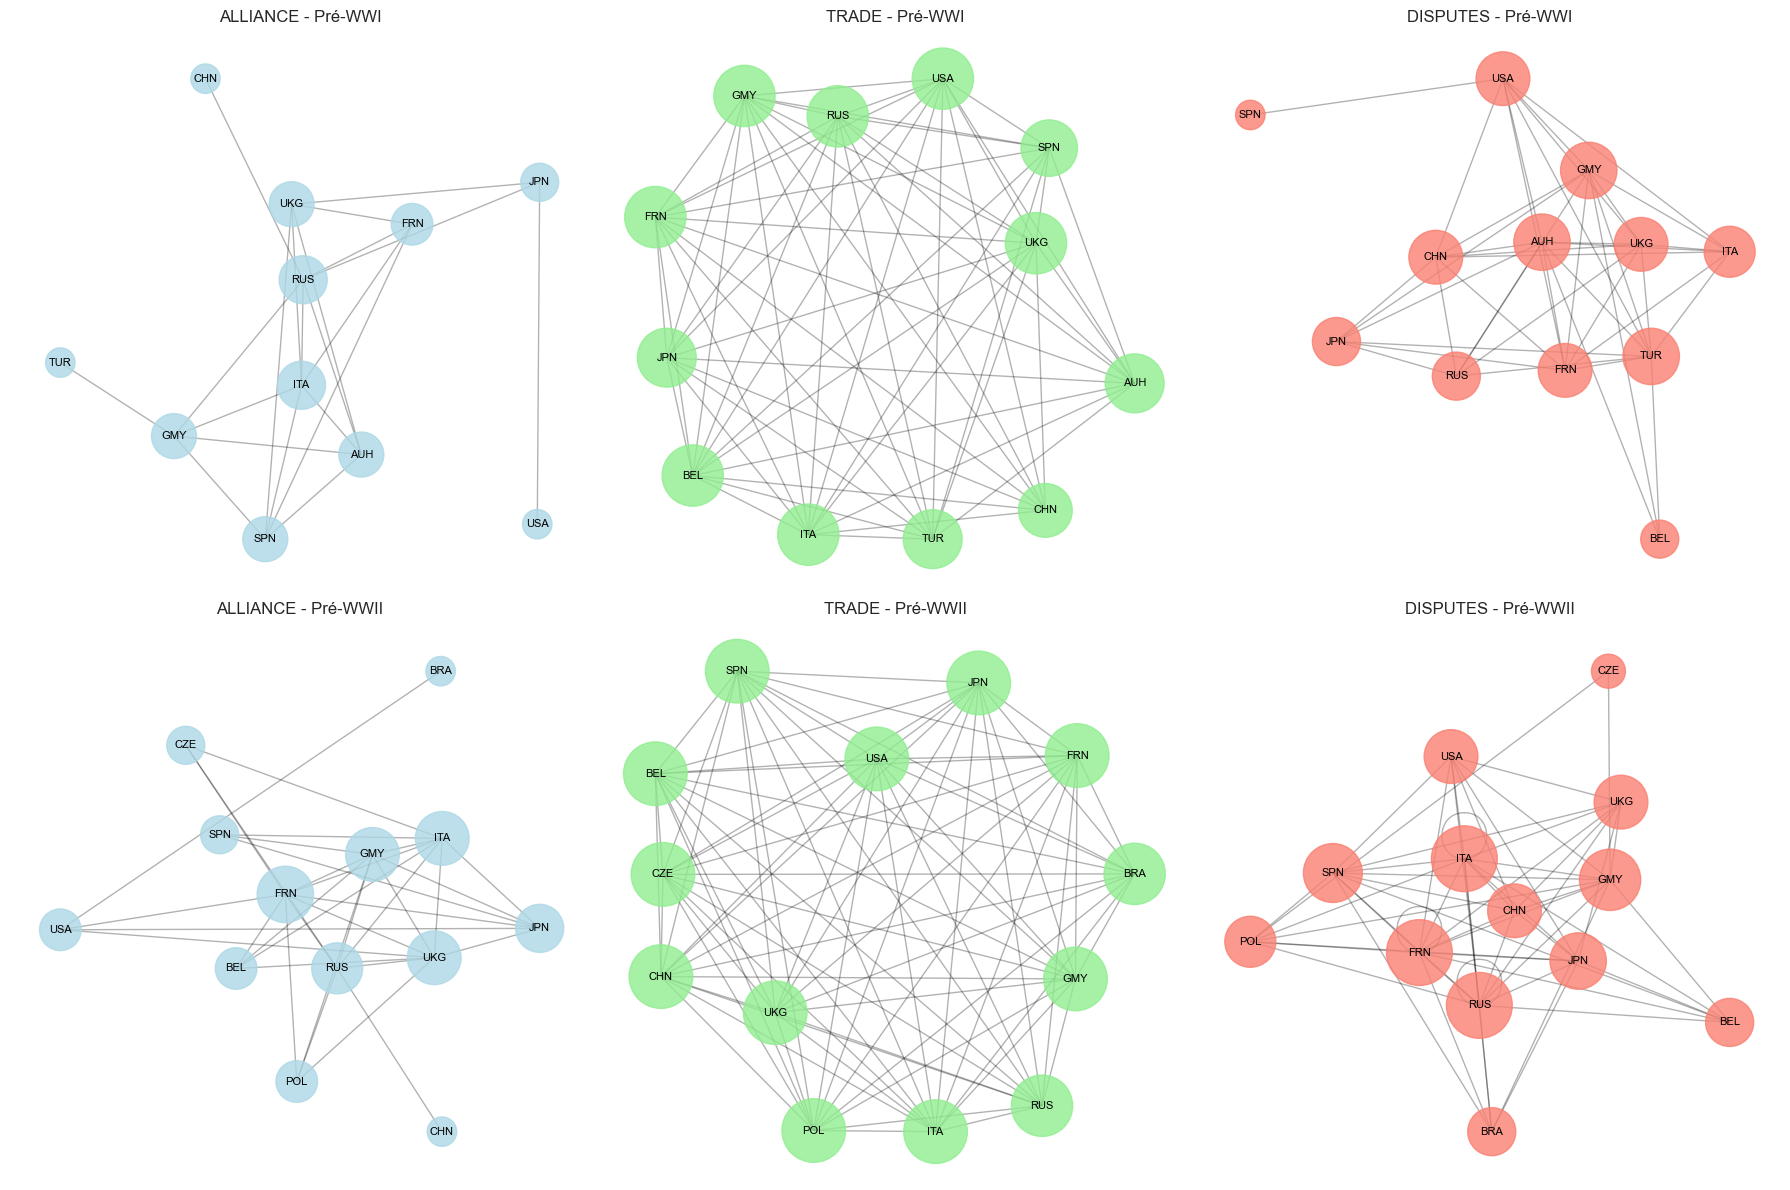

In [8]:
def draw_network(G, title, ax, names_dict, node_color='lightblue'):
    """Desenha rede com layout spring."""
    if G.number_of_nodes() == 0:
        ax.text(0.5, 0.5, 'Sem dados', ha='center', va='center')
        ax.set_title(title)
        return
    
    pos = nx.spring_layout(G, seed=42, k=2)
    
    # Tamanho dos nós proporcional ao grau
    degrees = dict(G.degree())
    node_sizes = [300 + degrees[n] * 150 for n in G.nodes()]
    
    # Desenhar
    nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.3, width=1)
    nx.draw_networkx_nodes(G, pos, ax=ax, node_size=node_sizes, 
                          node_color=node_color, alpha=0.8)
    
    # Labels
    labels = {n: names_dict.get(n, str(n)) for n in G.nodes()}
    nx.draw_networkx_labels(G, pos, labels, ax=ax, font_size=8)
    
    ax.set_title(title)
    ax.axis('off')


# Visualização comparativa por camada
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

colors = {'alliance': 'lightblue', 'trade': 'lightgreen', 'disputes': 'salmon'}

for i, layer in enumerate(['alliance', 'trade', 'disputes']):
    draw_network(networks_wwi[layer], f'{layer.upper()} - Pré-WWI', 
                axes[0, i], names_wwi, colors[layer])
    draw_network(networks_wwii[layer], f'{layer.upper()} - Pré-WWII', 
                axes[1, i], names_wwii, colors[layer])

plt.tight_layout()
plt.savefig(OUTPUT_PATH / 'redes_multilayer_comparacao.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Teste de Robustez: Variando CINC Threshold

In [9]:
# Testar diferentes thresholds CINC
thresholds = [0.005, 0.01, 0.015, 0.02]
robustness_results = []

for threshold in thresholds:
    for period_key in ['pre_wwi', 'pre_wwii']:
        period = PERIODS[period_key]
        
        try:
            networks, names = build_all_networks(period_key, threshold)
            
            for layer, G in networks.items():
                if G.number_of_nodes() > 0:
                    robustness_results.append({
                        'threshold': threshold,
                        'period': period['label'],
                        'layer': layer,
                        'nodes': G.number_of_nodes(),
                        'edges': G.number_of_edges(),
                        'density': nx.density(G)
                    })
        except Exception as e:
            print(f"Erro com threshold {threshold}, {period_key}: {e}")

robustness_df = pd.DataFrame(robustness_results)
print("\nResultados de Robustez:")
robustness_df


Construindo redes para Pré-WWI (1890-1914)

Estados com CINC >= 0.005: 17
['USA', 'MEX', 'BRA', 'UKG', 'NTH', 'BEL', 'FRN', 'SPN', 'GMY', 'AUH', 'ITA', 'RUS', 'SWD', 'ETH', 'TUR', 'CHN', 'JPN']

--- Rede de Alianças ---
Nós: 12, Arestas: 22

--- Rede de Comércio ---
Nós: 17, Arestas: 104

--- Rede de Disputas ---
Nós: 16, Arestas: 52

Construindo redes para Pré-WWII (1925-1939)

Estados com CINC >= 0.005: 24
['USA', 'CAN', 'MEX', 'BRA', 'ARG', 'UKG', 'NTH', 'BEL', 'FRN', 'SPN', 'GMY', 'POL', 'AUS', 'CZE', 'ITA', 'YUG', 'ROM', 'RUS', 'SWD', 'ETH', 'TUR', 'CHN', 'JPN', 'AUL']

--- Rede de Alianças ---
Nós: 20, Arestas: 60

--- Rede de Comércio ---
Nós: 24, Arestas: 257

--- Rede de Disputas ---
Nós: 23, Arestas: 112

Construindo redes para Pré-WWI (1890-1914)

Estados com CINC >= 0.01: 12
['USA', 'UKG', 'BEL', 'FRN', 'SPN', 'GMY', 'AUH', 'ITA', 'RUS', 'TUR', 'CHN', 'JPN']

--- Rede de Alianças ---
Nós: 11, Arestas: 21

--- Rede de Comércio ---
Nós: 12, Arestas: 62

--- Rede de Disputas 

,threshold,period,layer,nodes,edges,density
0,0.005,Pré-WWI (1890-1914),alliance,12,22,0.333333
1,0.005,Pré-WWI (1890-1914),trade,17,104,0.764706
2,0.005,Pré-WWI (1890-1914),disputes,16,52,0.433333
3,0.005,Pré-WWII (1925-1939),alliance,20,60,0.315789
4,0.005,Pré-WWII (1925-1939),trade,24,257,0.931159
5,0.005,Pré-WWII (1925-1939),disputes,23,112,0.442688
6,0.010,Pré-WWI (1890-1914),alliance,11,21,0.381818
7,0.010,Pré-WWI (1890-1914),trade,12,62,0.939394
8,0.010,Pré-WWI (1890-1914),disputes,12,41,0.621212
9,0.010,Pré-WWII (1925-1939),alliance,13,33,0.423077


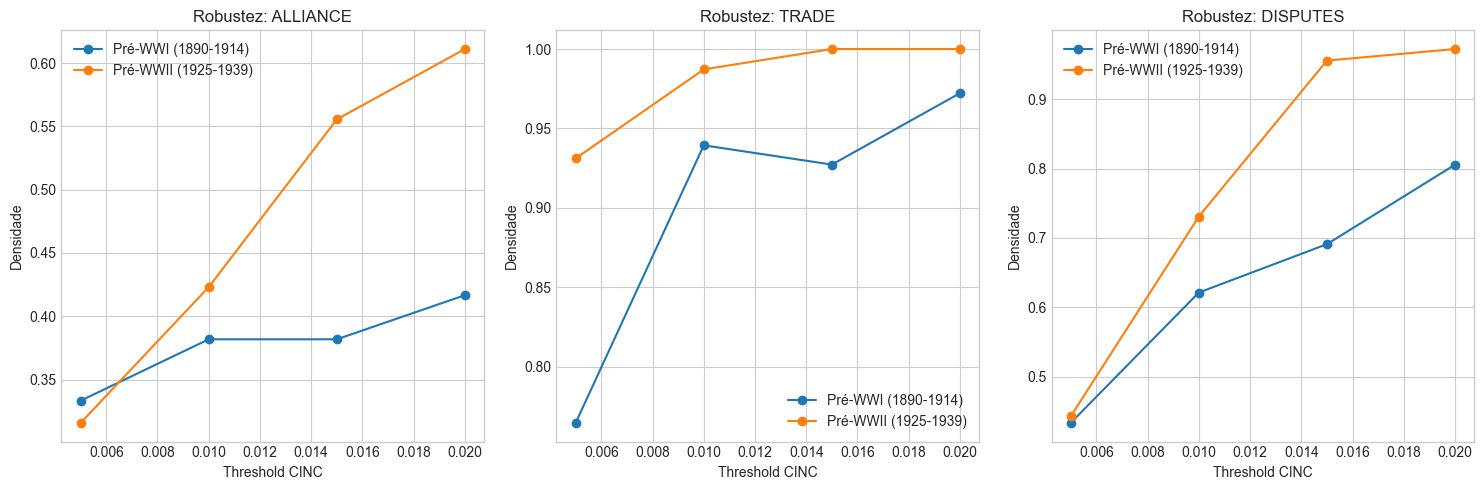

In [10]:
# Visualizar robustez
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, layer in zip(axes, ['alliance', 'trade', 'disputes']):
    layer_data = robustness_df[robustness_df['layer'] == layer]
    
    for period in layer_data['period'].unique():
        period_data = layer_data[layer_data['period'] == period]
        ax.plot(period_data['threshold'], period_data['density'], 
               marker='o', label=period)
    
    ax.set_xlabel('Threshold CINC')
    ax.set_ylabel('Densidade')
    ax.set_title(f'Robustez: {layer.upper()}')
    ax.legend()

plt.tight_layout()
plt.savefig(OUTPUT_PATH / 'robustez_cinc.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Rede Multilayer Integrada

In [11]:
# Combinar as 3 camadas em uma rede multilayer
G_multi_wwi = merge_networks(networks_wwi, combine_weights='sum')
G_multi_wwii = merge_networks(networks_wwii, combine_weights='sum')

print("Rede Multilayer Pré-WWI:")
print(f"  Nós: {G_multi_wwi.number_of_nodes()}")
print(f"  Arestas: {G_multi_wwi.number_of_edges()}")

print("\nRede Multilayer Pré-WWII:")
print(f"  Nós: {G_multi_wwii.number_of_nodes()}")
print(f"  Arestas: {G_multi_wwii.number_of_edges()}")

# Exportar para Gephi
export_to_gexf(G_multi_wwi, OUTPUT_PATH / 'rede_multilayer_pre_wwi.gexf')
export_to_gexf(G_multi_wwii, OUTPUT_PATH / 'rede_multilayer_pre_wwii.gexf')
print("\nArquivos GEXF exportados.")

Rede Multilayer Pré-WWI:
  Nós: 12
  Arestas: 63

Rede Multilayer Pré-WWII:
  Nós: 13
  Arestas: 81
Grafo exportado para: ../data/output/rede_multilayer_pre_wwi.gexf
Grafo exportado para: ../data/output/rede_multilayer_pre_wwii.gexf

Arquivos GEXF exportados.


## 10. Resumo e Conclusões Preliminares

In [13]:
# Resumo comparativo
summary = all_metrics.pivot_table(
    index='layer', 
    columns='period', 
    values=['density', 'avg_degree', 'modularity', 'edges'],
    aggfunc='first'
)

print("\n" + "="*60)
print("RESUMO COMPARATIVO")
print("="*60)
print(summary.to_string())

# Salvar resumo
all_metrics.to_csv(OUTPUT_PATH / 'metricas_multilayer.csv', index=False)
robustness_df.to_csv(OUTPUT_PATH / 'robustez_cinc.csv', index=False)
print("\nArquivos CSV salvos.")


RESUMO COMPARATIVO
         avg_degree              density             edges          modularity          
period      Pré-WWI   Pré-WWII   Pré-WWI  Pré-WWII Pré-WWI Pré-WWII    Pré-WWI  Pré-WWII
layer                                                                                   
alliance   3.818182   5.076923  0.381818  0.423077      21       33   0.247226  0.141250
disputes   6.833333   8.769231  0.621212  0.730769      41       57   0.170817  0.157972
trade     10.333333  11.846154  0.939394  0.987179      62       77   0.100176  0.062024

Arquivos CSV salvos.


---

## Observações Metodológicas

1. **Sem causalidade**: As comparações são puramente estruturais e descritivas
2. **Robustez testada**: Variamos o threshold CINC para verificar estabilidade
3. **Limitações**: 
   - Dados de disputas podem ter viés de registro
   - Comércio tem valores faltantes (-9)
   - Período pré-WWI tem mais dados históricos consolidados